In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Bank_of_America_Cleaned.csv")

print("Rows and Columns:", df.shape)
print("Column names:", df.columns.tolist())
df.head()


Rows and Columns: (13329, 11)
Column names: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ticker', 'name', 'Zero_Volume_Flag', 'Year', 'Close_Outlier_Flag']


,Date,Open,High,Low,Close,Volume,ticker,name,Zero_Volume_Flag,Year,Close_Outlier_Flag
0,1973-02-21 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,99200,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
1,1973-02-22 00:00:00-05:00,1.512735,1.512735,1.512735,1.512735,47200,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
2,1973-02-23 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,133600,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
3,1973-02-26 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,24000,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
4,1973-02-27 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,41600,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False


In [5]:
df["Date"] = pd.to_datetime(df["Date"], utc= True)
df = df.sort_values("Date").reset_index(drop=True)

df["Daily_Return"] = df["Close"].pct_change(fill_method=None)

returns = df["Daily_Return"].dropna()

worst_day = df.loc[
    df["Daily_Return"].idxmin(),
    ["Date", "Daily_Return"]
]

print("Average daily return:", f"{returns.mean():.2%}")
print("Daily return volarility:", f"{returns.std():.2%}")
print("Worst daily return:", f"{worst_day['Daily_Return']:.2%}")
print("Date of worst return:", worst_day["Date"])


Average daily return: 0.05%
Daily return volarility: 2.36%
Worst daily return: -28.97%
Date of worst return: 2009-01-20 05:00:00+00:00


In [6]:
worst_idx = df["Daily_Return"].idxmin()

df.loc[
    worst_idx - 2 : worst_idx + 2,
    ["Date", "Open", "High", "Low", "Close",
     "Volume", "Daily_Return", "Close_Outlier_Flag"]
]

,Date,Open,High,Low,Close,Volume,Daily_Return,Close_Outlier_Flag
9062,2009-01-15 05:00:00+00:00,7.486881,7.502318,5.673049,6.421737,552512600,-0.184313,False
9063,2009-01-16 05:00:00+00:00,6.938872,7.193581,5.402904,5.541836,494599400,-0.137019,False
9064,2009-01-20 05:00:00+00:00,5.001543,5.016979,3.897807,3.936399,413433500,-0.289694,False
9065,2009-01-21 05:00:00+00:00,4.276013,5.310283,4.137081,5.155914,438488400,0.309805,False
9066,2009-01-22 05:00:00+00:00,4.916643,4.939798,4.245139,4.407226,362515000,-0.145210,False


In [7]:
negative_days = (returns < 0).sum()
large_loss_days = (returns <= -0.05).sum()

print("Days with a negative return:", negative_days)
print("Days with a loss of 5% or more:", large_loss_days)

df.loc[
    df["Daily_Return"] <= -0.05,
    ["Date", "Daily_Return", "Volume"]
].sort_values("Daily_Return").head(10)

Days with a negative return: 5931
Days with a loss of 5% or more: 225


,Date,Daily_Return,Volume
9064,2009-01-20 05:00:00+00:00,-0.289694,413433500
8993,2008-10-07 04:00:00+00:00,-0.262259,143285000
9091,2009-02-27 05:00:00+00:00,-0.257519,476468300
9126,2009-04-20 04:00:00+00:00,-0.243396,802467300
8977,2008-09-15 04:00:00+00:00,-0.213100,275947400
9031,2008-12-01 05:00:00+00:00,-0.209231,127347400
9707,2011-08-08 04:00:00+00:00,-0.203182,682052900
9079,2009-02-10 05:00:00+00:00,-0.193033,608904400
3705,1987-10-19 04:00:00+00:00,-0.184971,1228400
9062,2009-01-15 05:00:00+00:00,-0.184313,552512600


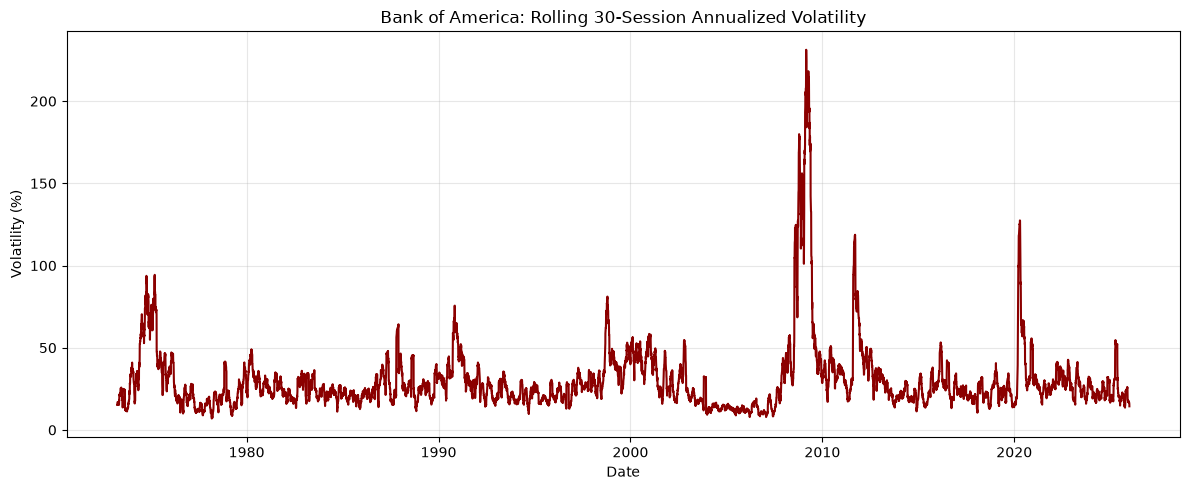

In [8]:
df["Rolling_30_Session_Volatility"] = (
    df["Daily_Return"].rolling(30).std() * (252 ** 0.5)
)

plt.figure(figsize=(12, 5))
plt.plot(
    df["Date"],
    df["Rolling_30_Session_Volatility"] * 100,
    color="darkred"
)
plt.title("Bank of America: Rolling 30-Session Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Week3_01_Rolling_Volatility.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
df["Running_Peak"] = df["Close"].cummax()
df["Drawdown"] = df["Close"] / df["Running_Peak"] - 1

trough_idx = df["Drawdown"].idxmin()
peak_idx = df.loc[:trough_idx, "Close"].idxmax()

print("Maximum drawdown:", f"{df.loc[trough_idx, 'Drawdown']:.2%}")
print("Peak date:", df.loc[peak_idx, "Date"])
print("Trough date:", df.loc[trough_idx, "Date"])

Maximum drawdown: -93.45%
Peak date: 2007-10-05 04:00:00+00:00
Trough date: 2009-03-06 05:00:00+00:00


In [10]:
print("Zero-volume rows:", df["Zero_Volume_Flag"].sum())
print("Closing-price outlier rows:", df["Close_Outlier_Flag"].sum())

df.loc[
    (df["Zero_Volume_Flag"] == True) |
    (df["Close_Outlier_Flag"] == True),
    ["Date", "Close", "Volume",
     "Zero_Volume_Flag", "Close_Outlier_Flag"]
].head(10)

Zero-volume rows: 6
Closing-price outlier rows: 66


,Date,Close,Volume,Zero_Volume_Flag,Close_Outlier_Flag
540,1975-04-11 04:00:00+00:00,0.453311,0,True,False
619,1975-08-04 04:00:00+00:00,0.458404,0,True,False
933,1976-10-28 04:00:00+00:00,0.402377,0,True,False
1474,1978-12-20 05:00:00+00:00,0.463497,0,True,False
2291,1982-03-17 05:00:00+00:00,0.555179,0,True,False
3291,1986-02-28 05:00:00+00:00,2.093378,0,True,False
13251,2025-09-11 04:00:00+00:00,50.487629,28055200,False,True
13254,2025-09-16 04:00:00+00:00,50.398094,31624400,False,True
13255,2025-09-17 04:00:00+00:00,51.134270,38337900,False,True
13256,2025-09-18 04:00:00+00:00,51.860497,35246900,False,True


In [11]:
annualized_volatility = returns.std() * (252 ** 0.5)

print("Annualized historical volatility:",
      f"{annualized_volatility:.2%}")


Annualized historical volatility: 37.52%


## Risk Register

**Scope:** This analysis assesses historical market-price and data/model risks in the Bank of America stock dataset. It does not assess the bank’s internal credit, operational, cybersecurity, or regulatory risks.

| Risk | Evidence from this analysis | Potential impact | Mitigation strategy |
|---|---|---|---|
| Market-price volatility | Annualized historical volatility was 37.52%; 225 sessions had a daily loss of 5% or more. | Large price swings can cause substantial short-term portfolio losses and make forecasts less reliable. | Monitor volatility, set exposure and loss limits, diversify holdings, and run stress scenarios. |
| Severe downside events | The worst observed daily return was −28.97%. | A sudden large decline can quickly reduce an investor’s position value. | Use scenario analysis, review exposure limits, and avoid relying on a single forecast or risk measure. |
| Historical drawdown | The observed maximum drawdown was −93.45% from October 5, 2007, to March 6, 2009. | A prolonged peak-to-trough decline can result in substantial capital loss and slow recovery. | Track drawdowns, review position size, and test portfolios against severe historical scenarios. |
| Data-quality and adjustment risk | The dataset contains 6 zero-volume rows and 66 closing-price outlier flags. The dataset does not provide an adjusted closing-price field. | Unverified records or corporate actions may distort returns, volatility, and drawdown estimates. | Validate flagged records with a reliable source, check split/dividend adjustments, and document any corrections before modelling. |
| Forecast-model risk | Week 2 used constant baseline forecasts and evaluated them on one 60-session test period. | The forecasts may fail to capture changing market conditions, trends, or sudden price movements. | Backtest across multiple periods, compare with suitable models, review errors regularly, and avoid using a baseline forecast alone for decisions. |

**Interpretation note:** Statistical outlier and zero-volume flags are review signals; they do not prove that a record is incorrect. This report describes historical observations and is not investment advice.